In [ ]:
# Instalação das bibliotecas necessárias
!pip install scikit-learn pandas google-generativeai
!pip install -U google-generativeai

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import google.generativeai as genai



/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
# =====================================================================
# PARTE 1: Geração de Dados Realistas (ETL Simulado)
# =====================================================================
np.random.seed(42) # Mantém os valores consistentes a cada execução

n_amostras = 1000

# 1. Gerando dados de AGVs Saudáveis (70% da frota)
# Temperaturas em torno de 80°C, baterias variadas, vibração baixa (~2.5Hz)
n_saudaveis = int(n_amostras * 0.7)
temp_saudavel = np.random.normal(loc=80, scale=5, size=n_saudaveis)
bat_saudavel = np.random.uniform(low=40, high=100, size=n_saudaveis)
vib_saudavel = np.random.normal(loc=2.5, scale=0.5, size=n_saudaveis)
status_saudavel = np.zeros(n_saudaveis) # 0 = Saudável

# 2. Gerando dados de AGVs com Falha (30% da frota)
# Temperaturas altas (~110°C), baterias mais baixas, vibração alta (~6.5Hz)
n_falhas = n_amostras - n_saudaveis
temp_falha = np.random.normal(loc=110, scale=8, size=n_falhas)
bat_falha = np.random.uniform(low=5, high=50, size=n_falhas)
vib_falha = np.random.normal(loc=6.5, scale=1.2, size=n_falhas)
status_falha = np.ones(n_falhas) # 1 = Falha Crítica

# 3. Consolidando no DataFrame e embaralhando
df_agv = pd.DataFrame({
    'Temperatura_Motor': np.concatenate([temp_saudavel, temp_falha]),
    'Nivel_Bateria': np.concatenate([bat_saudavel, bat_falha]),
    'Vibracao_Chassi': np.concatenate([vib_saudavel, vib_falha]),
    'Status_Falha': np.concatenate([status_saudavel, status_falha])
})
df_agv = df_agv.sample(frac=1, random_state=42).reset_index(drop=True)

print("--- Amostra do Dataset Gerado ---")
print(df_agv.head(), "\n")



--- Amostra do Dataset Gerado ---
   Temperatura_Motor  Nivel_Bateria  Vibracao_Chassi  Status_Falha
0          82.716801      97.108707         2.775743           0.0
1         114.104683      15.175640         5.388343           1.0
2         104.868147      15.368750         5.999160           1.0
3          77.131690      80.052994         1.903037           0.0
4          74.376790      83.895371         3.069939           0.0 



In [ ]:
# =====================================================================
# PARTE 2: Treinamento da Árvore de Decisão
# =====================================================================
X = df_agv[['Temperatura_Motor', 'Nivel_Bateria', 'Vibracao_Chassi']]
y = df_agv['Status_Falha']

# Separando em dados de treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_agv = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_agv.fit(X_train, y_train)

# Avaliando o modelo
acuracia = accuracy_score(y_test, modelo_agv.predict(X_test))
print(f"--- Performance do Modelo ---")
print(f"Acurácia da Árvore de Decisão: {acuracia * 100:.2f}%\n")

# Simulando um AGV com problemas para passar para o Gemini
nova_leitura = pd.DataFrame({
    'Temperatura_Motor': [108.5],
    'Nivel_Bateria': [22.0],
    'Vibracao_Chassi': [5.8]
})

previsao = modelo_agv.predict(nova_leitura)[0]
diagnostico_tecnico = "Alerta: Falha Crítica Iminente" if previsao == 1 else "Operação Saudável"

print(f"--- Diagnóstico Operacional ---")
print(f"Leitura -> Temp: {nova_leitura['Temperatura_Motor'][0]}°C | Bat: {nova_leitura['Nivel_Bateria'][0]}% | Vib: {nova_leitura['Vibracao_Chassi'][0]}Hz")
print(f"Decisão: {diagnostico_tecnico}\n")



--- Performance do Modelo ---
Acurácia da Árvore de Decisão: 99.50%

--- Diagnóstico Operacional ---
Leitura -> Temp: 108.5°C | Bat: 22.0% | Vib: 5.8Hz
Decisão: Alerta: Falha Crítica Iminente



In [ ]:
# =====================================================================
# PARTE 3: Integração com IA Generativa (Gemini)
# =====================================================================
from google.colab import userdata
import google.generativeai as genai

GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

model = genai.GenerativeModel('gemini-2.5-flash')

prompt = f"""
Você é a inteligência co-piloto do projeto SmartLog. Nosso sistema especialista (Árvore de Decisão)
analisou a telemetria de um AGV logístico em rota e gerou o seguinte diagnóstico:

[DADOS DA TELEMETRIA]
- Temperatura do Motor: {nova_leitura['Temperatura_Motor'][0]:.1f}°C
- Nível de Bateria Atual: {nova_leitura['Nivel_Bateria'][0]:.1f}%
- Frequência de Vibração do Chassi: {nova_leitura['Vibracao_Chassi'][0]:.1f}Hz

[DIAGNÓSTICO DO SISTEMA]
- Status: {diagnostico_tecnico}

Gere um relatório operacional conciso (máximo de 2 parágrafos e alguns bullet points) contendo:
1. Uma explicação técnica de como esses três sensores indicam o estado mecânico/elétrico do AGV.
2. Duas ações corretivas imediatas para a central de controle.
"""

resposta_interpretativa = model.generate_content(prompt)

print(f"--- Relatório Interpretativo (Gemini Co-Piloto) ---")
print(resposta_interpretativa.text)

--- Relatório Interpretativo (Gemini Co-Piloto) ---
**Relatório Operacional SmartLog - AGV em Rota**

O sistema especialista SmartLog identificou um estado de 'Alerta: Falha Crítica Iminente' no AGV, baseado em dados de telemetria que indicam uma convergência preocupante de problemas mecânicos e elétricos. A **Temperatura do Motor a 108.5°C** sinaliza sobrecarga severa, atrito excessivo ou falha de refrigeração, comprometendo a integridade mecânica e elétrica do drivetrain. O **Nível de Bateria em 22.0%** indica esgotamento iminente, que, além de causar parada inesperada, pode levar o motor a operar com menor eficiência e maior esforço, exacerbando o superaquecimento. A **Frequência de Vibração do Chassi em 5.8Hz** é um forte indicativo de desbalanceamento mecânico, desgaste de rolamentos ou componentes soltos no sistema de propulsão, evidenciando um estresse que, em conjunto com os outros fatores, cria um cenário de alto risco para uma quebra súbita e completa do AGV.

Diante desta si

In [ ]:
# =====================================================================
# PARTE 4: Implementação da Inteligência Evolutiva (RNA - TensorFlow/Keras)
# =====================================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

print("--- Iniciando o Treinamento da Rede Neural Preditiva ---")

# 1. Arquitetura da Rede Neural
# Camada de entrada (3 features: Temp, Bat, Vib), camadas ocultas para aprender padrões complexos e saída Sigmoid (Probabilidade 0 a 1)
modelo_rna = Sequential([
    Dense(16, activation='relu', input_shape=(3,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 2. Compilação do modelo (Otimizador Adam para ajuste dinâmico dos pesos)
modelo_rna.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Treinamento com histórico para avaliação de evolução
historico_rna = modelo_rna.fit(
    X_train, y_train,
    epochs=50,          # Número de ciclos de aprendizado
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0           # Oculta os logs de cada epoch para manter o output limpo
)

# Avaliação final
loss, accuracy = modelo_rna.evaluate(X_test, y_test, verbose=0)
print(f"Treinamento Concluído! Acurácia Final da RNA: {accuracy * 100:.2f}%")

--- Iniciando o Treinamento da Rede Neural Preditiva ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinamento Concluído! Acurácia Final da RNA: 100.00%


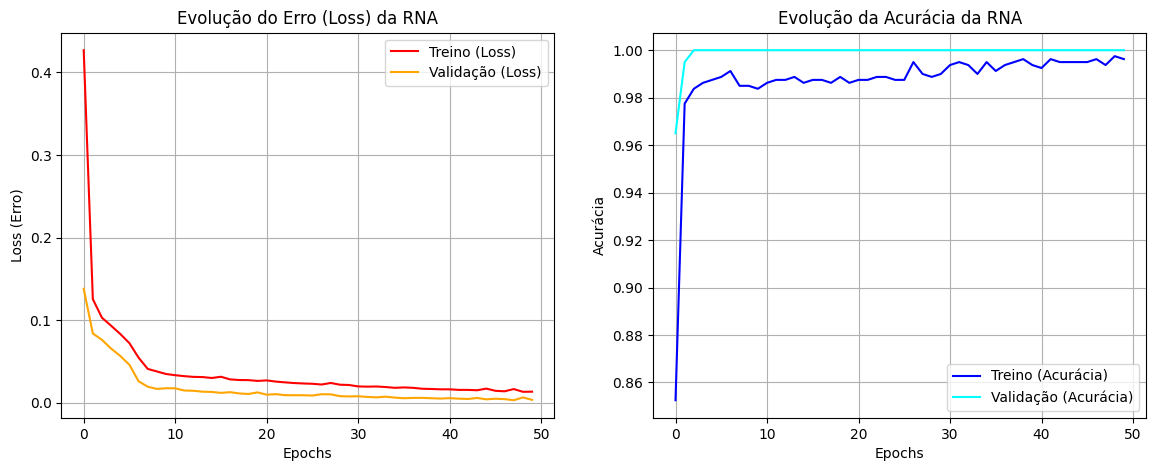

In [ ]:
# =====================================================================
# PARTE 5: Gráficos de Evolução do Aprendizado (Loss e Accuracy)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Evolução da Perda (Loss) - Deve cair com o tempo
ax1.plot(historico_rna.history['loss'], label='Treino (Loss)', color='red')
ax1.plot(historico_rna.history['val_loss'], label='Validação (Loss)', color='orange')
ax1.set_title('Evolução do Erro (Loss) da RNA')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (Erro)')
ax1.legend()
ax1.grid(True)

# Gráfico 2: Evolução da Acurácia (Fitness) - Deve subir com o tempo
ax2.plot(historico_rna.history['accuracy'], label='Treino (Acurácia)', color='blue')
ax2.plot(historico_rna.history['val_accuracy'], label='Validação (Acurácia)', color='cyan')
ax2.set_title('Evolução da Acurácia da RNA')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Acurácia')
ax2.legend()
ax2.grid(True)

plt.show()

In [ ]:
# =====================================================================
# PARTE 6: Previsão Preditiva, Atuadores e Integração com LLM (Gemini)
# =====================================================================

# Simulando uma leitura que a Árvore de Decisão original considerou falha,
# mas vamos ver a probabilidade exata da RNA.
probabilidade_falha = modelo_rna.predict(nova_leitura, verbose=0)[0][0]

print(f"\\n--- Comparação de Modelos ---")
print(f"Decisão da Árvore (Etapa 2): {diagnostico_tecnico}")
print(f"Probabilidade RNA (Etapa 3): {probabilidade_falha * 100:.2f}% de chance de falha crítica.")

# Lógica de Atuadores (Nova Lógica com RNA)
acao_atuador = ""
if probabilidade_falha > 0.85:
    acao_atuador = "ATUADOR ACIONADO: Desligamento emergencial do motor e freio travado."
elif probabilidade_falha > 0.50:
    acao_atuador = "ATUADOR ACIONADO: Redução de velocidade em 50% e desvio de rota para manutenção."
else:
    acao_atuador = "ATUADOR OCIOSO: Manter velocidade de cruzeiro."

print(f"\\nStatus do Atuador: {acao_atuador}\\n")

# Prompt atualizado para o Gemini focar na previsão
prompt_evolutivo = f"""
Atue como Analista Preditivo do SmartLog.
Recebemos a seguinte telemetria de um AGV: Temperatura {nova_leitura['Temperatura_Motor'][0]:.1f}°C, Bateria {nova_leitura['Nivel_Bateria'][0]:.1f}%, Vibração {nova_leitura['Vibracao_Chassi'][0]:.1f}Hz.

Nossa nova Rede Neural previu uma probabilidade de falha de {probabilidade_falha * 100:.2f}%.
O sistema tomou a seguinte decisão: {acao_atuador}

Escreva um relatório operacional de 1 parágrafo explicando:
1. Como o modelo preditivo ajudou a evitar uma quebra (baseado nessa probabilidade).
2. Se a ação do atuador foi adequada e por quê.
"""

resposta_evolutiva = model.generate_content(prompt_evolutivo)
print("--- Relatório Preditivo (Gemini API) ---")
print(resposta_evolutiva.text)

\n--- Comparação de Modelos ---
Decisão da Árvore (Etapa 2): Alerta: Falha Crítica Iminente
Probabilidade RNA (Etapa 3): 100.00% de chance de falha crítica.
\nStatus do Atuador: ATUADOR ACIONADO: Desligamento emergencial do motor e freio travado.\n
--- Relatório Preditivo (Gemini API) ---
A telemetria do AGV, com Temperatura de 108.5°C, Bateria em 22.0% e Vibração de 5.8Hz, foi imediatamente processada por nossa Rede Neural, cuja detecção de uma probabilidade de falha de 100.00% foi crucial para a proteção do ativo. Este alto grau de certeza indicou uma condição de criticidade extrema e iminente, permitindo que o SmartLog atuasse de forma preventiva e estratégica, evitando uma quebra inesperada que poderia resultar em danos ao equipamento, à carga ou interrupções operacionais não planejadas. Consequentemente, a decisão do sistema de acionar o atuador para um desligamento emergencial do motor e o travamento do freio foi absolutamente adequada e essencial; diante de uma probabilidade de 